# Chain-of-Thought Ablation Analysis

Does enabling chain-of-thought (CoT) reasoning improve LLM negotiation performance — and at what computational cost?

This notebook analyses a controlled ablation study comparing **CoT** (`enable_thinking=True`) against **No-CoT** (`enable_thinking=False`) in self-play negotiations across three games: **Trading**, **Ultimatum**, and **BuySell**.  
Change `MODEL_SIZE` below to switch between model scales.

In [26]:
MODEL_SIZE = "very_small"   # "very_small" (Qwen3.5-9B) or "medium" (Qwen3.5-27B)

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

colormap = sns.color_palette("Blues")
sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({"font.size": 22})
sns.set(font_scale=2.4)

LOGS_ROOT = "../../.logs/"
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

COT_ABLATION_ROOT = os.path.join(LOGS_ROOT, "cot_ablation")
SIZE_DIR = f"cot_{MODEL_SIZE}"
SIZE_LABEL = MODEL_SIZE.replace("_", " ").title()

GAME_CONFIGS = [
    ("Trading",   "trading_cot"),
    ("Ultimatum", "ultimatum_cot"),
    ("BuySell",   "buysell_cot"),
]

# Detect CoT / No-CoT pair directories from disk
def _detect_pairs(game_prefix):
    scan = os.path.join(COT_ABLATION_ROOT, game_prefix, SIZE_DIR)
    cot_pair, nocot_pair = None, None
    if os.path.isdir(scan):
        for d in sorted(os.listdir(scan)):
            full = os.path.join(scan, d)
            if not os.path.isdir(full):
                continue
            if "_thinking_" in d or d.endswith("_thinking"):
                cot_pair = d
            elif nocot_pair is None:
                nocot_pair = d
    return cot_pair, nocot_pair

COT_PAIR, NOCOT_PAIR = None, None
for _, gp in GAME_CONFIGS:
    c, n = _detect_pairs(gp)
    if c and n:
        COT_PAIR, NOCOT_PAIR = c, n
        break

if COT_PAIR is None or NOCOT_PAIR is None:
    raise FileNotFoundError(
        f"No CoT ablation data found for MODEL_SIZE='{MODEL_SIZE}' "
        f"in {COT_ABLATION_ROOT}. Check that cot_{MODEL_SIZE}/ dirs exist."
    )

CONDITIONS = [("CoT", COT_PAIR), ("No-CoT", NOCOT_PAIR)]

cond_colors = {
    "CoT":    sns.color_palette("colorblind")[0],
    "No-CoT": sns.color_palette("colorblind")[2],
}

print(f"Model size : {SIZE_LABEL}")
print(f"CoT pair   : {COT_PAIR}")
print(f"No-CoT pair: {NOCOT_PAIR}")

Model size : Very Small
CoT pair   : qwen3.5-9b_thinking_vs_qwen3.5-9b_thinking
No-CoT pair: qwen3.5-9b_vs_qwen3.5-9b


## Experimental Design

| Dimension | Value |
|--|-|
| **Model** | Qwen3.5 (size selected above) |
| **Conditions** | CoT (`enable_thinking=True`) vs No-CoT (`enable_thinking=False`) |
| **Games** | Trading (resource exchange), Ultimatum ($100 split), BuySell (price negotiation) |
| **Play mode** | Self-play (same model on both sides) |
| **Runs** | 30 per game per condition (Trading & Ultimatum); fewer for BuySell |
| **Max iterations** | 8 turns per game |
| **Parse retries** | 0 (no error correction) |

In [ ]:

def resource_value(res):
    """Total value of a resource dict (e.g. {"_type": "resource", "_value": {"X": 10, "Y": 5}})."""
    return sum(res["_value"].values())


def _game_dir(game_prefix, pair):
    return os.path.join(COT_ABLATION_ROOT, game_prefix, SIZE_DIR, pair)


# Data loaders
def load_completion_data():
    """Load completion status for every game run."""
    rows = []
    for game_name, game_prefix in GAME_CONFIGS:
        for cond_label, pair in CONDITIONS:
            gdir = _game_dir(game_prefix, pair)
            if not os.path.isdir(gdir):
                continue
            for root, _, files in os.walk(gdir):
                if "game_state.json" not in files:
                    continue
                try:
                    with open(os.path.join(root, "game_state.json")) as f:
                        data = json.load(f)
                    ci = data["game_state"][-1].get("current_iteration")
                    rows.append({
                        "game": game_name,
                        "condition": cond_label,
                        "completed": ci == "END",
                        "status": ci if ci in ("END", "ERROR") else "INCOMPLETE",
                    })
                except Exception:
                    pass
    return pd.DataFrame(rows)


def load_outcome_data():
    """Load per-game outcomes for completed games."""
    rows = []
    for game_name, game_prefix in GAME_CONFIGS:
        for cond_label, pair in CONDITIONS:
            gdir = _game_dir(game_prefix, pair)
            if not os.path.isdir(gdir):
                continue
            for root, _, files in os.walk(gdir):
                if "game_state.json" not in files:
                    continue
                try:
                    with open(os.path.join(root, "game_state.json")) as f:
                        data = json.load(f)
                    last = data["game_state"][-1]
                    if last.get("current_iteration") != "END":
                        continue
                    summary = last["summary"]
                    turns = [s for s in data["game_state"]
                             if s.get("current_iteration") not in ("START", "END")]
                    row = {
                        "game": game_name,
                        "condition": cond_label,
                        "num_turns": len(turns),
                        "final_response": summary.get("final_response", ""),
                    }
                    if game_name in ("Trading", "Ultimatum"):
                        init = summary["initial_resources"]
                        final = summary["final_resources"]
                        d1 = resource_value(final[0]) - resource_value(init[0])
                        d2 = resource_value(final[1]) - resource_value(init[1])
                        if game_name == "Ultimatum":
                            d1 = d1 + 100
                            if d1 == 100:
                                d1 = 0
                        row["payoff_1"] = d1
                        row["payoff_2"] = d2
                    elif game_name == "BuySell":
                        outcome = summary["player_outcome"]
                        row["payoff_1"] = outcome[0]
                        row["payoff_2"] = outcome[1]
                    rows.append(row)
                except Exception:
                    pass
    df = pd.DataFrame(rows)
    if not df.empty:
        df["surplus"] = df["payoff_1"].fillna(0) + df["payoff_2"].fillna(0)
    return df


def load_token_data():
    """Load character-count statistics (proxy for tokens) per completed game."""
    rows = []
    for game_name, game_prefix in GAME_CONFIGS:
        for cond_label, pair in CONDITIONS:
            gdir = _game_dir(game_prefix, pair)
            if not os.path.isdir(gdir):
                continue
            for root, _, files in os.walk(gdir):
                if "game_state.json" not in files:
                    continue
                try:
                    with open(os.path.join(root, "game_state.json")) as f:
                        data = json.load(f)
                    last = data["game_state"][-1]
                    if last.get("current_iteration") != "END":
                        continue
                    turns = [s for s in data["game_state"]
                             if s.get("current_iteration") not in ("START", "END")]
                    total_thinking = 0
                    total_content = 0
                    for player in data["players"]:
                        for msg in player.get("conversation", []):
                            if msg.get("role") != "assistant":
                                continue
                            total_content += len(msg.get("content", ""))
                            thinking = msg.get("thinking")
                            if thinking:
                                total_thinking += len(str(thinking))
                    rows.append({
                        "game": game_name,
                        "condition": cond_label,
                        "total_thinking_chars": total_thinking,
                        "total_content_chars": total_content,
                        "total_chars": total_thinking + total_content,
                        "num_turns": len(turns),
                    })
                except Exception:
                    pass
    return pd.DataFrame(rows)

def mann_whitney(a, b):
    """Two-sided Mann-Whitney U test. Returns (U, p)."""
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return u, p


def cohens_d(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    pooled = np.sqrt(((n1 - 1) * a.std(ddof=1)**2 + (n2 - 1) * b.std(ddof=1)**2) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan


def bootstrap_ci(data, stat_func=np.mean, n_boot=10000, alpha=0.05):
    """Return (lower, upper) bootstrap CI."""
    data = np.asarray(data, dtype=float)
    data = data[~np.isnan(data)]
    if len(data) < 2:
        val = stat_func(data) if len(data) == 1 else np.nan
        return val, val
    rng = np.random.default_rng(42)
    boots = [stat_func(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(boots, 100 * alpha / 2)
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return lo, hi


def format_p(p):
    if np.isnan(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."

In [28]:
# Load all datasets
df_comp = load_completion_data()
df_outcomes = load_outcome_data()
df_tokens = load_token_data()

# Sample-size summary
print(f"{'Game':<12} {'Condition':<8} {'Total':>6} {'Completed':>10}")
for game in ["Trading", "Ultimatum", "BuySell"]:
    for cond in ["CoT", "No-CoT"]:
        sub = df_comp[(df_comp["game"] == game) & (df_comp["condition"] == cond)]
        total = len(sub)
        done = int(sub["completed"].sum())
        print(f"{game:<12} {cond:<8} {total:>6} {done:>10}")

print(f"\nOutcome records : {len(df_outcomes)}")
print(f"Token records   : {len(df_tokens)}")

Game         Condition  Total  Completed
Trading      CoT          30         21
Trading      No-CoT       30         13
Ultimatum    CoT          30         15
Ultimatum    No-CoT       30         19
BuySell      CoT           3          2
BuySell      No-CoT        3          3

Outcome records : 73
Token records   : 73



## 1. Game Completion Rates

Does CoT help models complete negotiations without parse errors or timeouts?  
A game is **completed** if the final iteration is `END`; otherwise it terminated with an `ERROR` or remained `INCOMPLETE`.

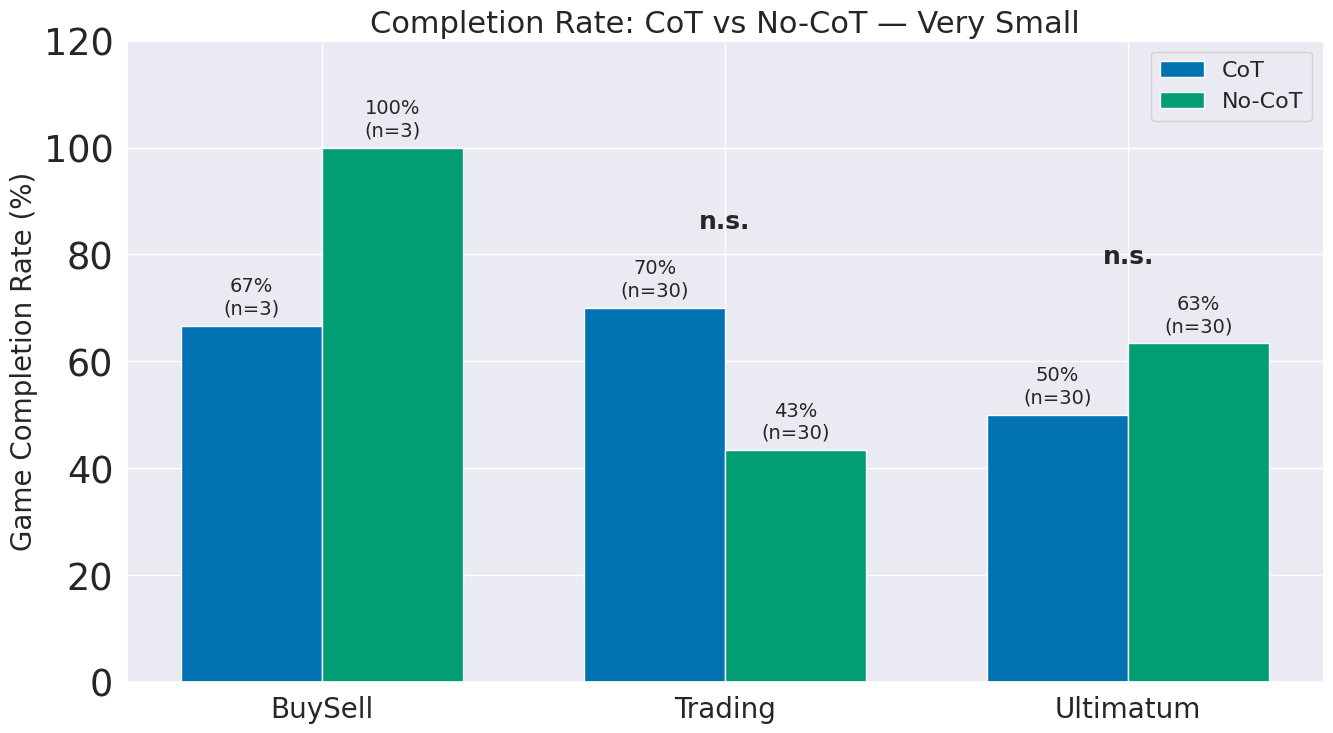

In [ ]:
# Completion rate bar chart with Fisher's exact tests
agg = df_comp.groupby(["game", "condition"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = sorted(agg["game"].unique())
conditions = ["CoT", "No-CoT"]
x = np.arange(len(games))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
for i, cond in enumerate(conditions):
    sub = agg[agg["condition"] == cond].set_index("game")
    vals = [sub.loc[g, "pct"] if g in sub.index else 0 for g in games]
    totals = [int(sub.loc[g, "total"]) if g in sub.index else 0 for g in games]
    bars = ax.bar(x + i * width, vals, width, label=cond, color=cond_colors[cond])
    for bar, val, tot in zip(bars, vals, totals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, val + 1.5,
            f"{val:.0f}%\n(n={tot})", ha="center", va="bottom", fontsize=14,
        )

ax.set_xticks(x + width / 2)
ax.set_xticklabels(games, fontsize=20)
ax.set_ylabel("Game Completion Rate (%)", fontsize=20)
ax.set_title(f"Completion Rate: CoT vs No-CoT — {SIZE_LABEL}", fontsize=22)
ax.set_ylim(0, 120)
ax.legend(fontsize=16)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/cot_{MODEL_SIZE}_completion_rates.pdf", bbox_inches="tight")
plt.show()

CoT helps completion in Trading but hurts in Buysell and Ultimatum


## 2. Negotiation Outcomes

Among games that completed successfully, does CoT produce better payoffs?

- **Trading:** resource deltas (zero-sum redistribution of X and Y goods)
- **Ultimatum:** proposer keeps / responder receives from a $100 pot
- **BuySell:** seller and buyer profit (limited data — shown as table)

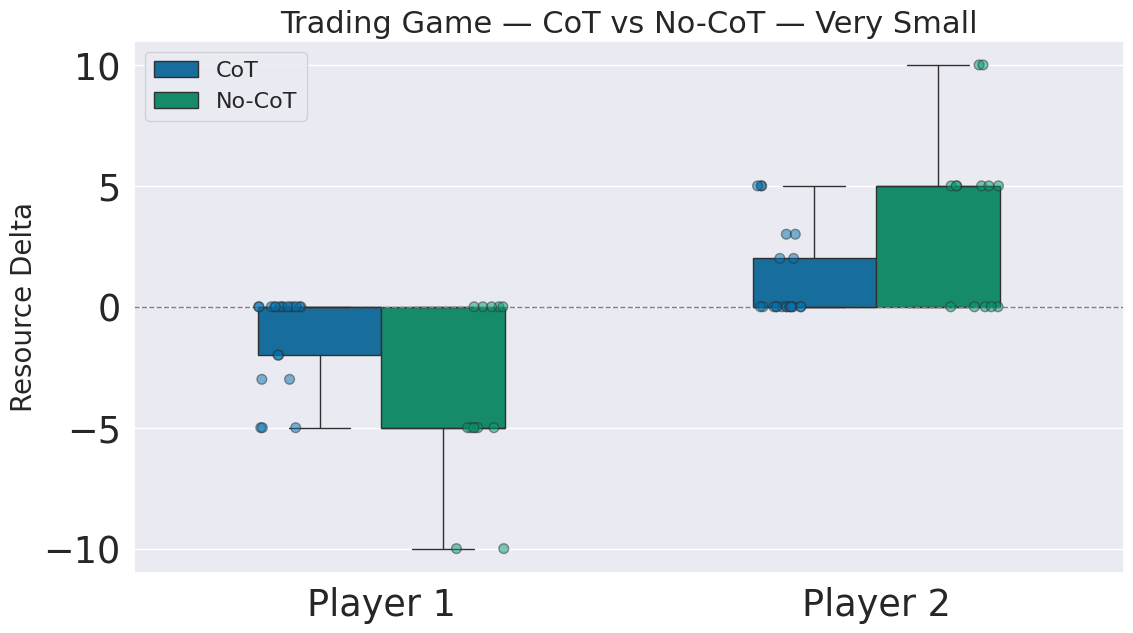

Player 1: CoT mean=-1.2 (n=21), No-CoT mean=-3.8 (n=13), U=194, p=0.0245 *, d=0.99
Player 2: CoT mean=1.2 (n=21), No-CoT mean=3.8 (n=13), U=79, p=0.0245 *, d=-0.99


In [ ]:
tdf = df_outcomes[df_outcomes["game"] == "Trading"].copy()

if not tdf.empty:
    plot_df = pd.melt(
        tdf, id_vars=["condition"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="payoff",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Player 1", "payoff_2": "Player 2"})

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.boxplot(data=plot_df, x="player", y="payoff", hue="condition",
                palette=cond_colors, ax=ax, width=0.5)
    sns.stripplot(data=plot_df, x="player", y="payoff", hue="condition",
                  palette=cond_colors, dodge=True, size=7, alpha=0.5,
                  linewidth=1, edgecolor="gray", ax=ax, legend=False)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_ylabel("Resource Delta", fontsize=20)
    ax.set_xlabel("")
    ax.set_title(f"Trading Game — CoT vs No-CoT — {SIZE_LABEL}", fontsize=22)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], fontsize=16)
    fig.tight_layout()
    #plt.savefig(f"{FIGURES_DIR}/cot_{MODEL_SIZE}_trading_outcomes.pdf", bbox_inches="tight")
    plt.show()

    # Stats
    for player, col in [("Player 1", "payoff_1"), ("Player 2", "payoff_2")]:
        cot_vals = tdf[tdf["condition"] == "CoT"][col].dropna()
        nocot_vals = tdf[tdf["condition"] == "No-CoT"][col].dropna()
        u, p = mann_whitney(cot_vals, nocot_vals)
        d = cohens_d(cot_vals, nocot_vals)
        print(f"{player}: CoT mean={cot_vals.mean():.1f} (n={len(cot_vals)}), "
              f"No-CoT mean={nocot_vals.mean():.1f} (n={len(nocot_vals)}), "
              f"U={u:.0f}, p={p:.4f} {format_p(p)}, d={d:.2f}")
else:
    print("No completed Trading games.")

CoT produces more conservative, balanced trades

CoT compresses both players' deltas toward zero (tighter boxes, smaller range), while No-CoT produces wider swings (P1 losing up to -10, P2 gaining up to +10). CoT reasoning appears to push the model toward "fair" exchanges where neither side gains much, the model is overthinking itself into cautious deals.


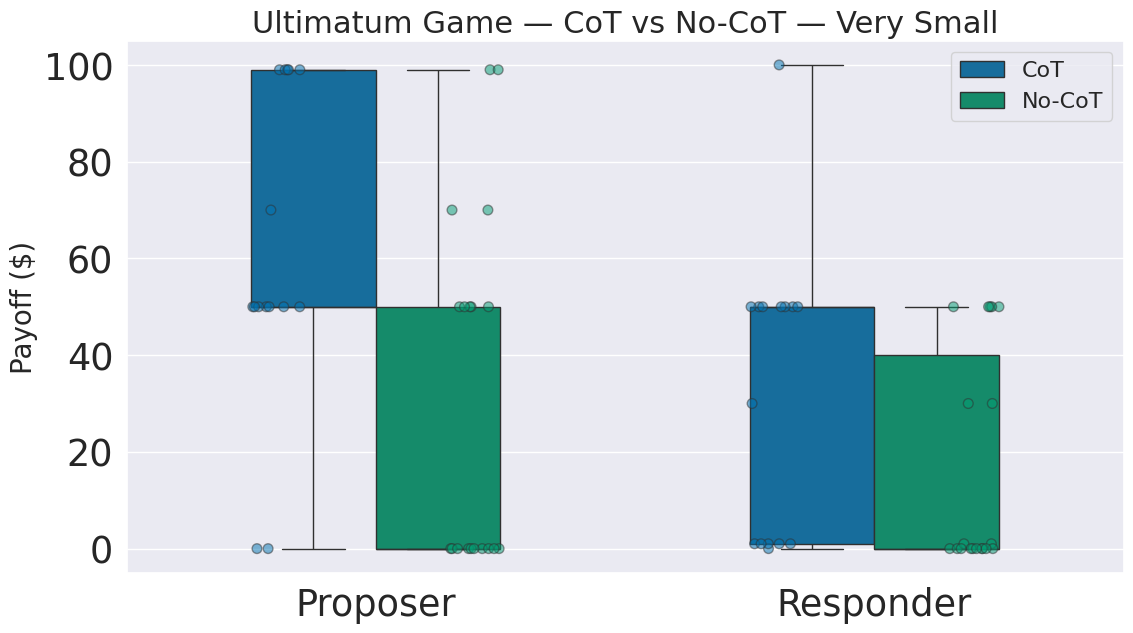

Proposer: CoT mean=61.0 (n=15), No-CoT mean=30.9 (n=19), U=204, p=0.0273 *, d=0.86
Responder: CoT mean=32.3 (n=15), No-CoT mean=16.4 (n=19), U=208, p=0.0193 *, d=0.61


In [ ]:
#  Ultimatum Game Outcomes 
udf = df_outcomes[df_outcomes["game"] == "Ultimatum"].copy()

if not udf.empty:
    plot_df = pd.melt(
        udf, id_vars=["condition"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="payoff",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Proposer", "payoff_2": "Responder"})

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.boxplot(data=plot_df, x="player", y="payoff", hue="condition",
                palette=cond_colors, ax=ax, width=0.5)
    sns.stripplot(data=plot_df, x="player", y="payoff", hue="condition",
                  palette=cond_colors, dodge=True, size=7, alpha=0.5,
                  linewidth=1, edgecolor="gray", ax=ax, legend=False)
    ax.set_ylabel("Payoff ($)", fontsize=20)
    ax.set_xlabel("")
    ax.set_title(f"Ultimatum Game — CoT vs No-CoT — {SIZE_LABEL}", fontsize=22)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], fontsize=16)
    fig.tight_layout()
    #plt.savefig(f"{FIGURES_DIR}/cot_{MODEL_SIZE}_ultimatum_outcomes.pdf", bbox_inches="tight")
    plt.show()

    # Stats
    for player, col in [("Proposer", "payoff_1"), ("Responder", "payoff_2")]:
        cot_vals = udf[udf["condition"] == "CoT"][col].dropna()
        nocot_vals = udf[udf["condition"] == "No-CoT"][col].dropna()
        u, p = mann_whitney(cot_vals, nocot_vals)
        d = cohens_d(cot_vals, nocot_vals)
        print(f"{player}: CoT mean={cot_vals.mean():.1f} (n={len(cot_vals)}), "
              f"No-CoT mean={nocot_vals.mean():.1f} (n={len(nocot_vals)}), "
              f"U={u:.0f}, p={p:.4f} {format_p(p)}, d={d:.2f}")
else:
    print("No completed Ultimatum games.")

  CoT proposers cluster heavily at keeping $99-100 (median ~$99), while No-CoT proposers are more spread out with a median around $50. CoT reasoning produces more persuasive justifications for unfair splits.



## 3. Computational Cost: Thinking Token Overhead

CoT enables an internal reasoning trace before each response. How much additional output does this produce?

Character counts are used as a token proxy. Since both conditions use the same model and tokenizer, relative comparisons are valid.

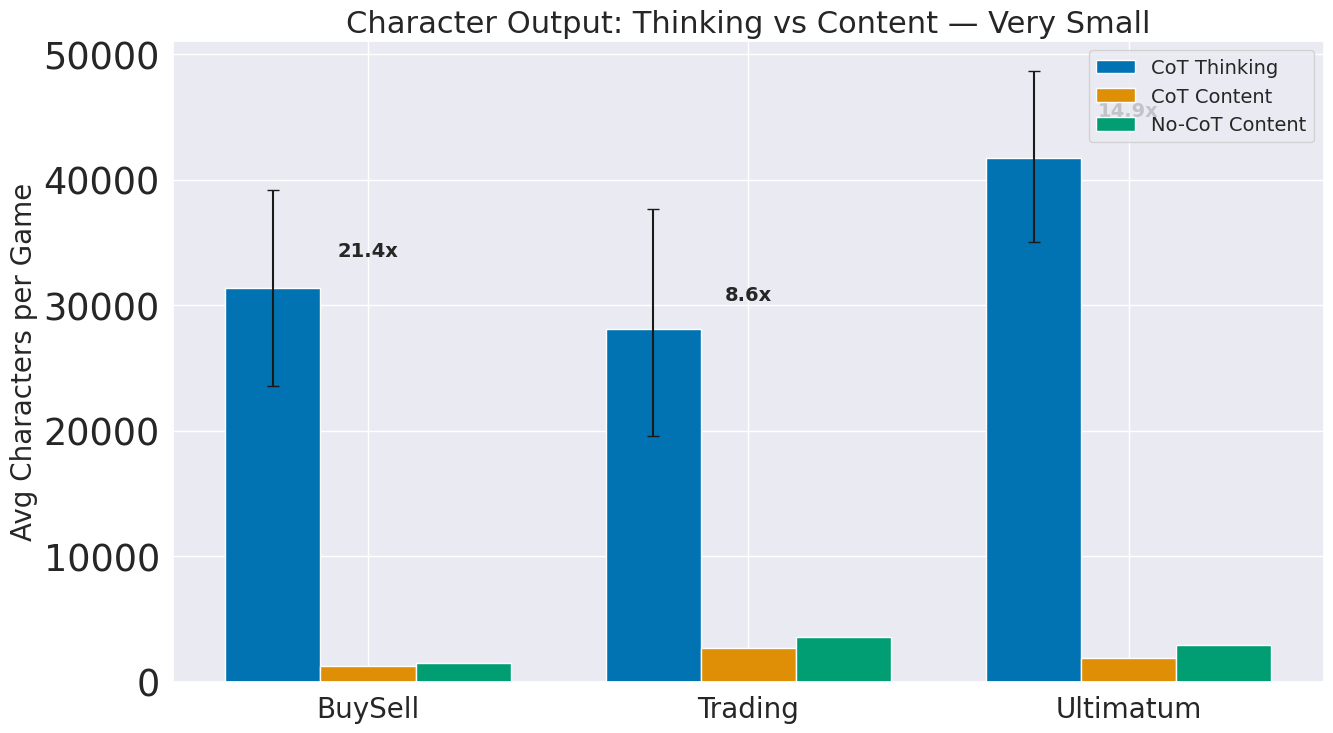

In [ ]:
if df_tokens.empty:
    print("No token data available.")
else:
    agg_t = df_tokens.groupby(["game", "condition"]).agg(
        thinking_mean=("total_thinking_chars", "mean"),
        content_mean=("total_content_chars", "mean"),
        total_mean=("total_chars", "mean"),
        n=("total_chars", "count"),
    ).reset_index()

    games = sorted(agg_t["game"].unique())
    x = np.arange(len(games))
    width = 0.25
    colors3 = sns.color_palette("colorblind", 3)

    fig, ax = plt.subplots(figsize=(14, 8))

    # CoT thinking
    cot = agg_t[agg_t["condition"] == "CoT"].set_index("game")
    vals_think = [cot.loc[g, "thinking_mean"] if g in cot.index else 0 for g in games]
    vals_content_cot = [cot.loc[g, "content_mean"] if g in cot.index else 0 for g in games]

    # Bootstrap CIs for thinking
    ci_think = []
    for g in games:
        gdata = df_tokens[(df_tokens["game"] == g) & (df_tokens["condition"] == "CoT")]["total_thinking_chars"]
        lo, hi = bootstrap_ci(gdata)
        ci_think.append((lo, hi))
    err_think = [[v - lo for v, (lo, hi) in zip(vals_think, ci_think)],
                 [hi - v for v, (lo, hi) in zip(vals_think, ci_think)]]

    ax.bar(x - width, vals_think, width, label="CoT Thinking", color=colors3[0],
           yerr=err_think, capsize=4, error_kw={"lw": 1.5})
    ax.bar(x, vals_content_cot, width, label="CoT Content", color=colors3[1])

    # No-CoT content
    nocot = agg_t[agg_t["condition"] == "No-CoT"].set_index("game")
    vals_content_nocot = [nocot.loc[g, "content_mean"] if g in nocot.index else 0 for g in games]
    ax.bar(x + width, vals_content_nocot, width, label="No-CoT Content", color=colors3[2])

    # Overhead multiplier annotation
    for i, g in enumerate(games):
        cot_total = (cot.loc[g, "total_mean"] if g in cot.index else 0)
        nocot_total = (nocot.loc[g, "content_mean"] if g in nocot.index else 1)
        if nocot_total > 0:
            ratio = cot_total / nocot_total
            ymax = max(vals_think[i], vals_content_cot[i], vals_content_nocot[i])
            ax.text(x[i], ymax * 1.08, f"{ratio:.1f}x", ha="center", fontsize=14, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(games, fontsize=20)
    ax.set_ylabel("Avg Characters per Game", fontsize=20)
    ax.set_title(f"Character Output: Thinking vs Content — {SIZE_LABEL}", fontsize=22)
    ax.legend(fontsize=14, loc="upper right")
    fig.tight_layout()
    #plt.savefig(f"{FIGURES_DIR}/cot_{MODEL_SIZE}_char_overhead.pdf", bbox_inches="tight")
    plt.show()

  - 8.6x to 21.4x total character overhead vs No-CoT
  - Thinking:content ratios of ~10x (Trading), ~20x (Ultimatum), ~25x (BuySell)
  - The model generates 25,000-42,000 characters of internal reasoning per game that never reaches the other player

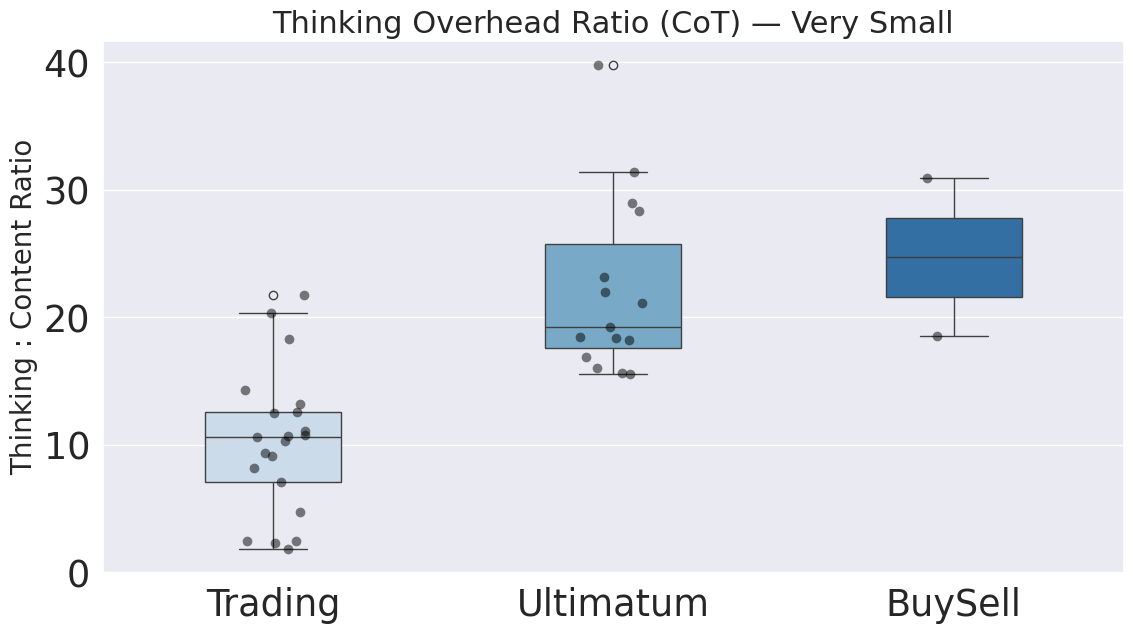

Thinking : Content ratio summary (CoT condition):


,mean,median,std,min,max,count
game,,,,,,
BuySell,24.71,24.71,8.79,18.50,30.92,2
Trading,10.18,10.59,5.66,1.84,21.77,21
Ultimatum,22.22,19.24,7.01,15.56,39.81,15



Interpretation: for every 1 character of visible output, the model produces ~15.7x characters of internal reasoning.


In [ ]:
#  Thinking : Content ratio analysis (CoT only) 
cot_tokens = df_tokens[df_tokens["condition"] == "CoT"].copy()

if not cot_tokens.empty and cot_tokens["total_content_chars"].sum() > 0:
    cot_tokens["thinking_ratio"] = cot_tokens["total_thinking_chars"] / cot_tokens["total_content_chars"]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.boxplot(data=cot_tokens, x="game", y="thinking_ratio",
                palette="Blues", ax=ax, width=0.4)
    sns.stripplot(data=cot_tokens, x="game", y="thinking_ratio",
                  color="black", size=7, alpha=0.5, ax=ax)
    ax.set_ylabel("Thinking : Content Ratio", fontsize=20)
    ax.set_xlabel("")
    ax.set_title(f"Thinking Overhead Ratio (CoT) — {SIZE_LABEL}", fontsize=22)
    fig.tight_layout()
    #plt.savefig(f"{FIGURES_DIR}/cot_{MODEL_SIZE}_thinking_ratio.pdf", bbox_inches="tight")
    plt.show()

    # Summary table
    ratio_summary = cot_tokens.groupby("game")["thinking_ratio"].agg(
        ["mean", "median", "std", "min", "max", "count"]
    ).round(2)
    print("Thinking : Content ratio summary (CoT condition):")
    display(ratio_summary)
    print(f"\nInterpretation: for every 1 character of visible output, the model produces "
          f"~{cot_tokens['thinking_ratio'].mean():.1f}x characters of internal reasoning.")
else:
    print("No CoT token data available.")


## 4. Negotiation Dynamics

Does CoT change how quickly negotiations resolve?

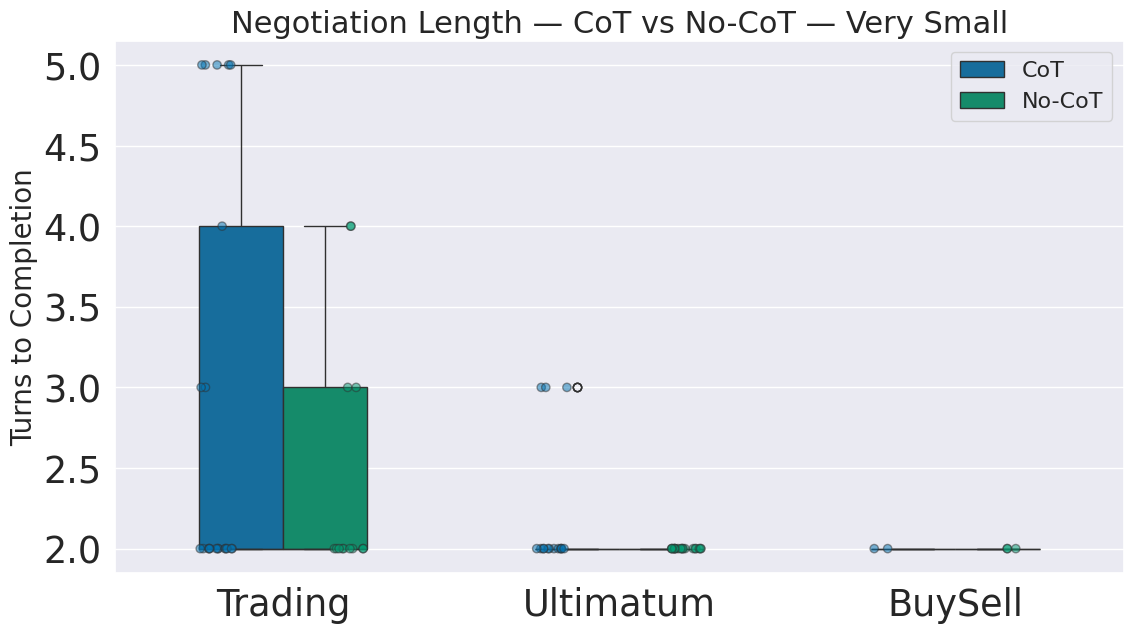

Turns comparison (Mann-Whitney U):
  BuySell      CoT=2.0 (n=2) vs No-CoT=2.0 (n=3), U=3, p=1.0000 n.s., d=nan
  Trading      CoT=2.9 (n=21) vs No-CoT=2.5 (n=13), U=156, p=0.4411 n.s., d=0.39
  Ultimatum    CoT=2.2 (n=15) vs No-CoT=2.0 (n=19), U=171, p=0.0482 *, d=0.73


In [ ]:
#  Turns to completion 
turns_df = df_outcomes[df_outcomes["game"].isin(
    df_outcomes.groupby("game").filter(lambda x: len(x) >= 4)["game"].unique()
)].copy()

if not turns_df.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.boxplot(data=turns_df, x="game", y="num_turns", hue="condition",
                palette=cond_colors, ax=ax, width=0.5)
    sns.stripplot(data=turns_df, x="game", y="num_turns", hue="condition",
                  palette=cond_colors, dodge=True, size=6, alpha=0.5,
                  linewidth=1, edgecolor="gray", ax=ax, legend=False)
    ax.set_ylabel("Turns to Completion", fontsize=20)
    ax.set_xlabel("")
    ax.set_title(f"Negotiation Length — CoT vs No-CoT — {SIZE_LABEL}", fontsize=22)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], fontsize=16)
    fig.tight_layout()
    #plt.savefig(f"{FIGURES_DIR}/cot_{MODEL_SIZE}_turns.pdf", bbox_inches="tight")
    plt.show()

    # Stats
    print("Turns comparison (Mann-Whitney U):")
    for game in sorted(turns_df["game"].unique()):
        g = turns_df[turns_df["game"] == game]
        cot_t = g[g["condition"] == "CoT"]["num_turns"]
        nocot_t = g[g["condition"] == "No-CoT"]["num_turns"]
        u, p = mann_whitney(cot_t, nocot_t)
        d = cohens_d(cot_t, nocot_t)
        print(f"  {game:<12} CoT={cot_t.mean():.1f} (n={len(cot_t)}) vs "
              f"No-CoT={nocot_t.mean():.1f} (n={len(nocot_t)}), "
              f"U={u:.0f}, p={p:.4f} {format_p(p)}, d={d:.2f}")
else:
    print("Not enough data for turns comparison.")

  Trading with CoT takes a median of 4 turns vs 3 for No-CoT. The "careful reasoning" leads to more counter-proposals before agreement. Ultimatum and BuySell resolve in 2 turns regardless.



## 5. Example Thinking Trace

A brief look at what the model reasons about internally during a CoT negotiation.

In [35]:
# Show 1-2 thinking trace examples from completed CoT games
MAX_CHARS = 3000
examples_shown = 0

for game_name, game_prefix in GAME_CONFIGS:
    if examples_shown >= 2:
        break
    gdir = _game_dir(game_prefix, COT_PAIR)
    if not os.path.isdir(gdir):
        continue
    for root, _, files in os.walk(gdir):
        if "game_state.json" not in files or examples_shown >= 2:
            continue
        try:
            with open(os.path.join(root, "game_state.json")) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            # Find first assistant message with thinking
            for player in data["players"]:
                for msg in player.get("conversation", []):
                    if msg.get("role") == "assistant" and msg.get("thinking"):
                        thinking = str(msg["thinking"])
                        # Get outcome
                        summary = last["summary"]
                        resp = summary.get("final_response", "N/A")
                        truncated = thinking[:MAX_CHARS]
                        if len(thinking) > MAX_CHARS:
                            truncated += "\n[... truncated ...]"

                        print(f"{'=' * 70}")
                        print(f"Game: {game_name} | Outcome: {resp} | "
                              f"Thinking length: {len(thinking):,} chars")
                        print(f"{'=' * 70}")
                        print(truncated)
                        print()
                        examples_shown += 1
                        break
                if examples_shown >= 2:
                    break
        except Exception:
            pass

if examples_shown == 0:
    print("No thinking traces found in completed CoT games.")

Game: Trading | Outcome: ACCEPT | Thinking length: 18,359 chars
Thinking Process:

1.  **Analyze the Request:**
    *   I am Player RED.
    *   I have resources: X: 25, Y: 5.
    *   I want to acquire as many resources as possible.
    *   I am playing a strategic trading game with Player BLUE.
    *   I have no knowledge of Player BLUE's resources.
    *   This is the last round of trading.
    *   I have a limit of 3 proposals.
    *   I need to follow specific XML-like tags for my response.
    *   I need to start by making a proposal.

2.  **Evaluate the Situation:**
    *   I have X: 25, Y: 5.
    *   I don't know what Player BLUE has.
    *   I want to maximize my total resources (X + Y).
    *   Since I don't know their inventory, I need to make an offer that is likely acceptable to them while trying to get something in return.
    *   A balanced trade is usually best. If I give too much, I lose. If I give too little, they reject.
    *   Since it's the last round, I need to cl

In [36]:
#  Comprehensive summary table 
summary_rows = []
for game in ["Trading", "Ultimatum", "BuySell"]:
    for cond in ["CoT", "No-CoT"]:
        row = {"Game": game, "Condition": cond}

        # Completion
        comp = df_comp[(df_comp["game"] == game) & (df_comp["condition"] == cond)]
        total = len(comp)
        done = int(comp["completed"].sum())
        row["n (total)"] = total
        row["n (completed)"] = done
        row["Completion %"] = f"{done / total * 100:.0f}" if total > 0 else "—"

        # Outcomes
        oc = df_outcomes[(df_outcomes["game"] == game) & (df_outcomes["condition"] == cond)]
        if not oc.empty:
            row["Mean P1 Payoff"] = f"{oc['payoff_1'].mean():.1f}"
            row["Mean P2 Payoff"] = f"{oc['payoff_2'].mean():.1f}"
            row["Mean Surplus"] = f"{oc['surplus'].mean():.1f}"
            row["Mean Turns"] = f"{oc['num_turns'].mean():.1f}"
        else:
            row["Mean P1 Payoff"] = "—"
            row["Mean P2 Payoff"] = "—"
            row["Mean Surplus"] = "—"
            row["Mean Turns"] = "—"

        # Tokens
        tk = df_tokens[(df_tokens["game"] == game) & (df_tokens["condition"] == cond)]
        if not tk.empty:
            row["Avg Chars"] = f"{int(tk['total_chars'].mean()):,}"
            if cond == "CoT" and tk["total_content_chars"].sum() > 0:
                ratio = tk["total_thinking_chars"].mean() / tk["total_content_chars"].mean()
                row["Think:Content"] = f"{ratio:.1f}x"
            else:
                row["Think:Content"] = "—"
        else:
            row["Avg Chars"] = "—"
            row["Think:Content"] = "—"

        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary.style.hide(axis="index"))

Game,Condition,n (total),n (completed),Completion %,Mean P1 Payoff,Mean P2 Payoff,Mean Surplus,Mean Turns,Avg Chars,Think:Content
Trading,CoT,30,21,70,-1.2,1.2,0.0,2.9,"30,810",10.5x
Trading,No-CoT,30,13,43,-3.8,3.8,0.0,2.5,"3,581",—
Ultimatum,CoT,30,15,50,61.0,32.3,93.3,2.2,"43,611",22.0x
Ultimatum,No-CoT,30,19,63,30.9,16.4,47.4,2.0,"2,921",—
BuySell,CoT,3,2,67,17.5,2.5,20.0,2.0,"32,644",24.7x
BuySell,No-CoT,3,3,100,7.0,13.0,20.0,2.0,"1,527",—
